In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [2]:
df = pd.read_csv("../data/processed/state_year_panel.csv")

In [3]:
print(df.shape)
print(df.dtypes)
df.head(10)

(1428, 16)
state                          object
year                            int64
fatalities                      int64
fatalities_under21              int64
fatalities_over21               int64
fatalities_age_unknown          int64
motorcycles                     int64
fatality_rate_per_10k_reg     float64
population                      int64
fatality_rate_per_100k_pop    float64
treated                         int64
repeal_year                   float64
event_time                    float64
post                            int64
exemption_age                 float64
reg_data_quality_flag          object
dtype: object


,state,year,fatalities,fatalities_under21,fatalities_over21,fatalities_age_unknown,motorcycles,fatality_rate_per_10k_reg,population,fatality_rate_per_100k_pop,treated,repeal_year,event_time,post,exemption_age,reg_data_quality_flag
0,Alabama,1995,33,4,29,0,37445,8.812926,4262731,0.774152,0,NaN,NaN,0,NaN,ok
1,Alabama,1996,31,3,28,0,36225,8.557626,4290403,0.722543,0,NaN,NaN,0,NaN,ok
2,Alabama,1997,29,4,25,0,38544,7.523869,4320281,0.671253,0,NaN,NaN,0,NaN,ok
3,Alabama,1998,34,8,26,0,44058,7.717100,4351037,0.781423,0,NaN,NaN,0,NaN,ok
4,Alabama,1999,32,5,27,0,48715,6.568819,4369862,0.732289,0,NaN,NaN,0,NaN,ok
5,Alabama,2000,43,7,36,0,54359,7.910374,4452173,0.965821,0,NaN,NaN,0,NaN,ok
6,Alabama,2001,43,4,39,0,54507,7.888895,4467634,0.962478,0,NaN,NaN,0,NaN,ok
7,Alabama,2002,43,2,41,0,61524,6.989142,4480089,0.959802,0,NaN,NaN,0,NaN,ok
8,Alabama,2003,52,2,50,0,70372,7.389303,4503491,1.154660,0,NaN,NaN,0,NaN,ok
9,Alabama,2004,75,7,68,0,80599,9.305326,4530729,1.655363,0,NaN,NaN,0,NaN,ok


In [4]:
# How many treated vs control states?
print(df["treated"].value_counts())

# Which states are treated and what are their repeal years?
print(
    df[df["treated"] == 1][["state", "repeal_year"]]
    .drop_duplicates()
    .sort_values("repeal_year")
)

treated
0    1232
1     196
Name: count, dtype: int64
             state  repeal_year
84        Arkansas       1997.0
1204         Texas       1997.0
476       Kentucky       1998.0
252        Florida       2000.0
1064  Pennsylvania       2003.0
616       Michigan       2012.0
700       Missouri       2020.0


## Investigating Suspicious Rows

In [5]:
# How many suspicious rows are there?
print(df["reg_data_quality_flag"].value_counts())

# What are the suspicious rows?
print(
    df[df["reg_data_quality_flag"] == "suspicious_low"][
        ["state", "year", "motorcycles", "fatality_rate_per_10k_reg"]
    ]
)

reg_data_quality_flag
ok                1424
suspicious_low       4
Name: count, dtype: int64
        state  year  motorcycles  fatality_rate_per_10k_reg
147  Colorado  2002         1115                 654.708520
148  Colorado  2003         7929                  88.283516
149  Colorado  2004         8325                  97.297297
740   Montana  2007        20284                  17.747979


Colorado 2002 shows 654 fatalities per 10,000 motorcycles, which is pretty much impossible. Most likely, this is a registration data error, not a real spike in deaths.

## Cleaning Data

In [ ]:
# Drop the 4 suspicious-registration rows (Colorado 2002-04, Montana 2007)
# and Missouri entirely. Missouri repealed in 2020, leaving only 3 post-period
# years, and its exemption age is 26 (not 21), which breaks the under-/over-21
# age-group split used later. See models/README.md §4.
df_clean = df[df["reg_data_quality_flag"] == "ok"].copy()
df_clean = df_clean[df_clean["state"] != "Missouri"].copy()

print(f"Original rows: {len(df)}")
print(f"Clean rows:    {len(df_clean)}")
print(f"Dropped:       {len(df) - len(df_clean)}")

## Variable Exploration

In [7]:
# Summary stats for our primary outcome, split by treated vs control
print(df_clean.groupby("treated")["fatality_rate_per_10k_reg"].describe().round(2))

          count  mean   std   min   25%   50%    75%    max
treated                                                    
0        1228.0  6.71  5.91  0.56  3.80  5.48   7.87  72.73
1         168.0  8.63  3.19  3.56  5.69  8.76  10.55  18.09


We can see that treated states have a higher average fatality rate (8.56 vs 6.71) overall, but this is okay for DiD. We don't need them to have the same levels, we just need them to move in parallel over time (we will test this later)

In [8]:
# Average fatality rate by year and treated status
trends = (
    df_clean.groupby(["year", "treated"])["fatality_rate_per_10k_reg"]
    .mean()
    .reset_index()
)

print(
    trends.pivot(
        index="year", columns="treated", values="fatality_rate_per_10k_reg"
    ).round(2)
)

treated     0      1
year                
1995     7.29   8.05
1996     6.41   8.08
1997     6.31   7.87
1998     6.79   8.31
1999     6.88   8.25
2000     7.65   9.01
2001     7.42   9.56
2002     7.70   8.42
2003     7.96   9.71
2004     8.46   9.08
2005     9.20  10.03
2006     7.36   9.93
2007     7.63  10.21
2008     8.11   9.36
2009     6.52   7.85
2010     5.87   8.55
2011     5.59   7.15
2012     5.83   8.04
2013     5.12   7.64
2014     5.02   7.00
2015     5.50   8.22
2016     5.82   8.88
2017     5.53   8.48
2018     5.98   8.07
2019     5.81   7.34
2020     6.73   8.67
2021     6.76   9.96
2022     6.67   9.81


We can notice a few things here:

- 1995-1996 (before any repeals): the two groups are pretty close (7.29 vs 8.05, 6.41 vs 8.08). This is encouraging for parallel trends
- Post-2000: treated states start pulling away from control states noticeably
- 2021-2022: the gap remains wide (6.67 vs 9.81), consistent with the cumulative effect of the earlier repeals

*Note: Missouri is excluded from `df_clean` (repeal = 2020, only 3 post-period years; see cell above), so the treated column reflects the six states repealing between 1997 and 2012.*

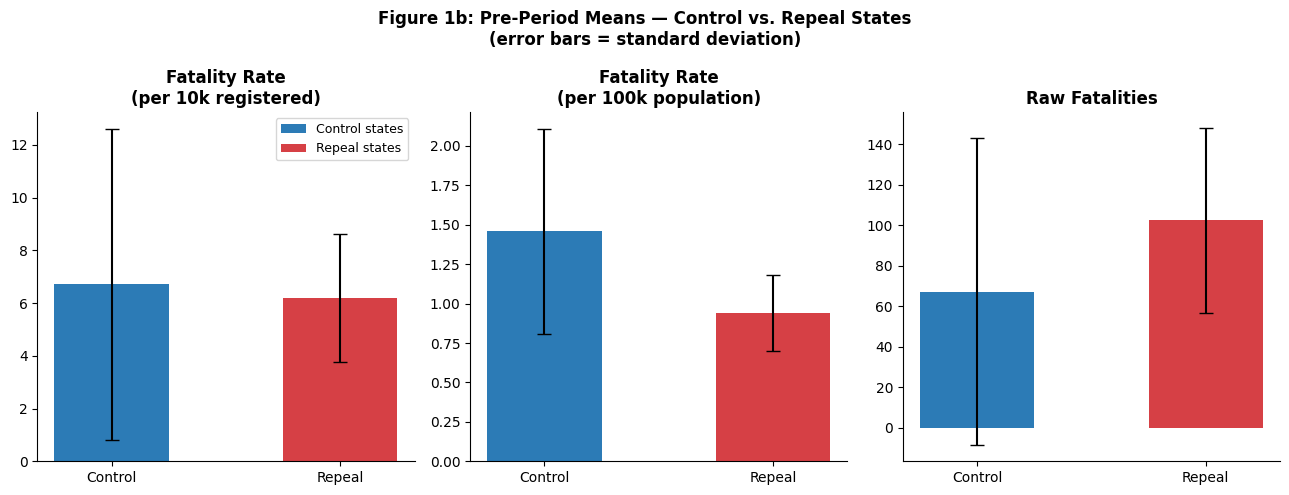

In [9]:
# Recreate pre-period dataset
pre = df_clean[(df_clean["treated"] == 0) | (df_clean["event_time"] < 0)].copy()

# Recreate summary
summary = (
    pre.groupby("treated")[
        [
            "fatality_rate_per_10k_reg",
            "fatality_rate_per_100k_pop",
            "fatalities",
            "motorcycles",
            "population",
        ]
    ]
    .agg(["mean", "std"])
    .round(2)
)

vars_plot = {
    "fatality_rate_per_10k_reg": "Fatality Rate\n(per 10k registered)",
    "fatality_rate_per_100k_pop": "Fatality Rate\n(per 100k population)",
    "fatalities": "Raw Fatalities",
}

control_means = [summary.loc[0, (var, "mean")] for var in vars_plot]
treat_means = [summary.loc[1, (var, "mean")] for var in vars_plot]
control_stds = [summary.loc[0, (var, "std")] for var in vars_plot]
treat_stds = [summary.loc[1, (var, "std")] for var in vars_plot]

x = np.arange(len(vars_plot))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for i, (ax, var, label) in enumerate(zip(axes, vars_plot.keys(), vars_plot.values())):
    ax.bar(
        0,
        control_means[i],
        width=0.5,
        color="#2C7BB6",
        yerr=control_stds[i],
        capsize=5,
        label="Control states",
    )
    ax.bar(
        1,
        treat_means[i],
        width=0.5,
        color="#D64045",
        yerr=treat_stds[i],
        capsize=5,
        label="Repeal states",
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Control", "Repeal"])
    ax.set_title(label, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if i == 0:
        ax.legend(fontsize=9)

fig.suptitle(
    "Figure 1b: Pre-Period Means — Control vs. Repeal States\n"
    "(error bars = standard deviation)",
    fontweight="bold",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## DiD (comparing motorcycle fatalities pre and post repeal of helmet safety laws)

### Running DiD

In [10]:
# Baseline DiD: state + year fixed effects, clustered SE by state
model1 = smf.ols(
    "fatality_rate_per_10k_reg ~ treated:post + C(state) + C(year)", data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["state"]})

# Pull out just the DiD coefficient
coef = model1.params["treated:post"]
se = model1.bse["treated:post"]
pval = model1.pvalues["treated:post"]
ci = model1.conf_int().loc["treated:post"]

print("DiD Coefficient (treated x post):", round(coef, 4))
print("Standard Error:                  ", round(se, 4))
print("p-value:                         ", round(pval, 4))
print("95% CI:                          ", [round(ci[0], 4), round(ci[1], 4)])

DiD Coefficient (treated x post): 1.4389
Standard Error:                   0.818
p-value:                          0.0786
95% CI:                           [np.float64(-0.1643), np.float64(3.0422)]


Coefficient of 1.44: This means that repealing a universal helmet law is associated with 1.44 additional fatalities per 10,000 registered motorcycles per year, compared to what would have been expected based on control states.
p-value of 0.079: This is marginally significant — not quite at the 5% level, but close. Under the population-based robustness check (Model 3 below) the same comparison is significant at the 1% level.
95% CI of [-0.16, 3.04]: the interval narrowly includes zero, so we can't rule out a zero effect at the 5% level with this specification alone.

In [11]:
# What is the pre-repeal mean for treated states?
pre_mean = df_clean[(df_clean["treated"] == 1) & (df_clean["event_time"] < 0)][
    "fatality_rate_per_10k_reg"
].mean()

print(f"Pre-repeal mean (treated states): {pre_mean:.2f}")
print(f"DiD coefficient:                  {coef:.2f}")
print(f"Percent increase:                 {(coef / pre_mean * 100):.1f}%")

Pre-repeal mean (treated states): 6.18
DiD coefficient:                  1.44
Percent increase:                 23.3%


States that repealed their universal helmet laws saw motorcycle fatality rates rise by about 1.4 deaths per 10,000 registered motorcycles per year, which is about a 23% increase over their pre-repeal baseline.

### Parallel Trends Assumption Testing

In [12]:
# Define our event time window
ET_MIN, ET_MAX = -6, 9
REF = -1  # reference year, normalized to 0

# Create a dummy for each event-time bin (treated states only)
for k in range(ET_MIN, ET_MAX + 1):
    if k == REF:
        continue
    col = f"et_{k}" if k >= 0 else f"et_m{abs(k)}"
    df_clean[col] = ((df_clean["event_time"] == k) & (df_clean["treated"] == 1)).astype(
        int
    )

# List them in order for reference
et_cols = [
    (k, f"et_{k}" if k >= 0 else f"et_m{abs(k)}")
    for k in range(ET_MIN, ET_MAX + 1)
    if k != REF
]

print("Event time dummies created:")
for k, col in et_cols:
    print(f"  {col}: n={df_clean[col].sum()}")

Event time dummies created:
  et_m6: n=2
  et_m5: n=3
  et_m4: n=3
  et_m3: n=4
  et_m2: n=6
  et_0: n=6
  et_1: n=6
  et_2: n=6
  et_3: n=6
  et_4: n=6
  et_5: n=6
  et_6: n=6
  et_7: n=6
  et_8: n=6
  et_9: n=6


In [13]:
# Build formula with all event time dummies
et_dummy_str = " + ".join([col for _, col in et_cols])
formula_es = f"fatality_rate_per_10k_reg ~ {et_dummy_str} + C(state) + C(year)"

model_es = smf.ols(formula_es, data=df_clean).fit(
    cov_type="cluster", cov_kwds={"groups": df_clean["state"]}
)

# Extract coefficients and CIs for each event time
es_results = []
for k, col in et_cols:
    coef = model_es.params[col]
    ci = model_es.conf_int().loc[col]
    es_results.append({"event_time": k, "coef": coef, "ci_lo": ci[0], "ci_hi": ci[1]})

# Add reference year as zero
es_results.append({"event_time": REF, "coef": 0.0, "ci_lo": 0.0, "ci_hi": 0.0})

es_df = pd.DataFrame(es_results).sort_values("event_time").reset_index(drop=True)
print(es_df.to_string(index=False))

 event_time      coef     ci_lo    ci_hi
         -6 -0.566534 -1.406945 0.273878
         -5 -0.307553 -1.395706 0.780600
         -4 -0.851808 -2.208468 0.504851
         -3 -0.980135 -3.166543 1.206272
         -2 -1.000571 -2.430154 0.429012
         -1  0.000000  0.000000 0.000000
          0 -0.090611 -2.345146 2.163923
          1  0.197509 -1.848421 2.243439
          2 -0.711494 -2.391105 0.968118
          3  0.275695 -1.216890 1.768280
          4 -0.051670 -2.010903 1.907564
          5 -0.473214 -2.683992 1.737564
          6  0.894429 -0.790450 2.579308
          7  0.413285 -1.697057 2.523628
          8  0.554225 -2.231256 3.339706
          9  1.008634 -1.899607 3.916875


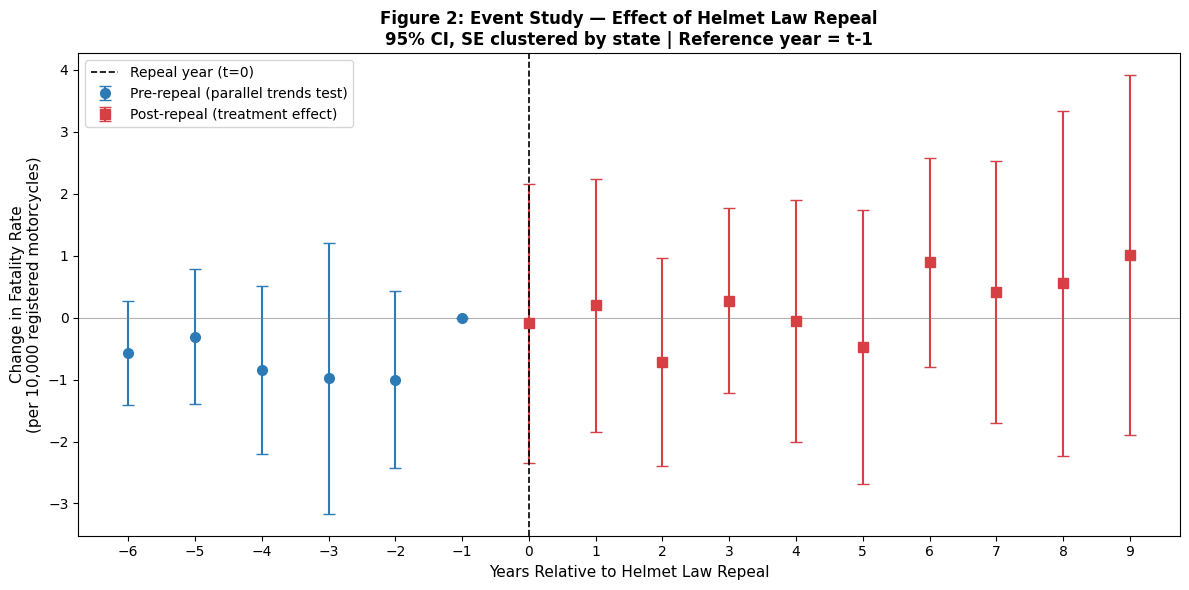

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

pre = es_df[es_df["event_time"] < 0]
post = es_df[es_df["event_time"] >= 0]

# Pre-period
ax.errorbar(
    pre["event_time"],
    pre["coef"],
    yerr=[pre["coef"] - pre["ci_lo"], pre["ci_hi"] - pre["coef"]],
    fmt="o",
    color="#2C7BB6",
    ecolor="#2C7BB6",
    elinewidth=1.5,
    capsize=4,
    markersize=7,
    label="Pre-repeal (parallel trends test)",
)

# Post-period
ax.errorbar(
    post["event_time"],
    post["coef"],
    yerr=[post["coef"] - post["ci_lo"], post["ci_hi"] - post["coef"]],
    fmt="s",
    color="#D64045",
    ecolor="#D64045",
    elinewidth=1.5,
    capsize=4,
    markersize=7,
    label="Post-repeal (treatment effect)",
)

ax.axvline(0, color="black", linestyle="--", linewidth=1.2, label="Repeal year (t=0)")
ax.axhline(0, color="gray", linestyle="-", linewidth=0.8, alpha=0.6)

ax.set_xlabel("Years Relative to Helmet Law Repeal", fontsize=11)
ax.set_ylabel(
    "Change in Fatality Rate\n(per 10,000 registered motorcycles)", fontsize=11
)
ax.set_title(
    "Figure 2: Event Study — Effect of Helmet Law Repeal\n"
    "95% CI, SE clustered by state | Reference year = t-1",
    fontweight="bold",
    fontsize=12,
)
ax.set_xticks(range(ET_MIN, ET_MAX + 1))
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

Pre-period (blue circles, t=-6 to t=-1):

- All coefficients are close to zero and all confidence intervals cross zero
- This supports the parallel trends assumption (before repeal, treated and control states were moving together)
- This is the most important thing for DiD validity

Post-period (red squares, t=0 to t=9):

- Coefficients are mostly positive, meaning fatalities increased after repeal
- The confidence intervals are wide (this is expected with only 6 treated states)
- The trend is generally upward over time, suggesting the effect may grow as more riders stop wearing helmets

In [15]:
pre_cols = [col for k, col in et_cols if k < 0]
ftest = model_es.f_test([f"{col} = 0" for col in pre_cols])

print("Joint F-test on pre-period coefficients")
print("H0: all pre-period coefficients = 0 (parallel trends holds)")
print("=" * 50)
print(f"F-statistic: {ftest.fvalue:.4f}")
print(f"p-value:     {ftest.pvalue:.4f}")
if ftest.pvalue > 0.10:
    print("✓ Fail to reject H0 — parallel trends assumption supported")
else:
    print("✗ Reject H0 — some pre-trend divergence detected")

Joint F-test on pre-period coefficients
H0: all pre-period coefficients = 0 (parallel trends holds)
F-statistic: 1.0203
p-value:     0.4160
✓ Fail to reject H0 — parallel trends assumption supported


A p-value of 0.42 means we cannot reject parallel trends because the pre-period differences between treated and control states are consistent with just random noise, not a systematic divergence. This means we can likely trust our DiD result.

### Trying Other Models with Extra Fun Stuff

In [16]:
# Model 2: add log(population) covariate
model2 = smf.ols(
    "fatality_rate_per_10k_reg ~ treated:post + np.log(population) + C(state) + C(year)",
    data=df_clean,
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["state"]})

# Model 3: robustness — per 100k population outcome
model3 = smf.ols(
    "fatality_rate_per_100k_pop ~ treated:post + C(state) + C(year)", data=df_clean
).fit(cov_type="cluster", cov_kwds={"groups": df_clean["state"]})

for name, model in [
    ("Model 2 (+ log population)", model2),
    ("Model 3 (per 100k pop)", model3),
]:
    c = model.params["treated:post"]
    se = model.bse["treated:post"]
    p = model.pvalues["treated:post"]
    ci = model.conf_int().loc["treated:post"]
    print(f"{name}")
    print(f"  Coef={c:.4f}  SE={se:.4f}  p={p:.4f}  95%CI=[{ci[0]:.4f}, {ci[1]:.4f}]")
    print()

Model 2 (+ log population)
  Coef=1.3680  SE=0.7587  p=0.0714  95%CI=[-0.1191, 2.8550]

Model 3 (per 100k pop)
  Coef=0.3511  SE=0.1329  p=0.0082  95%CI=[0.0906, 0.6116]



In [17]:
rows = []
for name, model, outcome in [
    ("(1) Baseline", model1, "Per 10k registered"),
    ("(2) + log(pop)", model2, "Per 10k registered"),
    ("(3) Per 100k pop", model3, "Per 100k population"),
]:
    c = model.params["treated:post"]
    se = model.bse["treated:post"]
    p = model.pvalues["treated:post"]
    ci = model.conf_int().loc["treated:post"]
    stars = "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.10 else ""))
    rows.append(
        {
            "Model": name,
            "Outcome": outcome,
            "DiD Coefficient": round(c, 4),
            "Std. Error": round(se, 4),
            "p-value": round(p, 4),
            "95% CI": f"[{ci[0]:.3f}, {ci[1]:.3f}]",
            "Sig.": stars,
            "N": int(model.nobs),
            "State FE": "Yes",
            "Year FE": "Yes",
            "Clustered SE": "State",
        }
    )

tbl2 = pd.DataFrame(rows)
print("Table 2: Difference-in-Differences Results")
print("* p<0.10  ** p<0.05  *** p<0.01")
tbl2

Table 2: Difference-in-Differences Results
* p<0.10  ** p<0.05  *** p<0.01


,Model,Outcome,DiD Coefficient,Std. Error,p-value,95% CI,Sig.,N,State FE,Year FE,Clustered SE
0,(1) Baseline,Per 10k registered,1.4389,0.8180,0.0786,"[-0.164, 3.042]",*,1396,Yes,Yes,State
1,(2) + log(pop),Per 10k registered,1.3680,0.7587,0.0714,"[-0.119, 2.855]",*,1396,Yes,Yes,State
2,(3) Per 100k pop,Per 100k population,0.3511,0.1329,0.0082,"[0.091, 0.612]",***,1396,Yes,Yes,State


#### Table 2: Difference-in-Differences Results

We estimate three specifications to test the robustness of our main finding. All models include state and year fixed effects with standard errors clustered by state.

**Model 1 (Baseline)**: Our primary specification. Repealing a universal helmet law is associated with **1.44 additional fatalities per 10,000 registered motorcycles** per year relative to control states (p=0.079). This represents a 23.3% increase over the pre-repeal baseline, though the 95% CI narrowly includes zero.

**Model 2 (+ log population)**: Adds log(population) as a covariate to control for differential state population growth over time. The coefficient is nearly unchanged at 1.37 (p=0.071), indicating that population dynamics are not driving our result.

**Model 3 (Robustness)**: Replaces the primary outcome with fatalities per 100,000 total population, using a denominator that does not rely on motorcycle registration data. Repealing states saw **0.35 additional fatalities per 100,000 residents** per year (p=0.008) — statistically significant at the 1% level. The smaller magnitude reflects the larger denominator, and the substantive conclusion is the same across all three models.

## Age Group DiD (over-21 riders vs. under-21 riders)

If the repeal is what's driving the fatality increase, it should show up disproportionately in the over-21 group since they're the ones newly exempt from the helmet requirement. Under-21 riders are still required to wear helmets, so they act as a within-state control group.

In [ ]:
# Compute age-group rates for treated states only
treated_only = df_clean[df_clean["treated"] == 1].copy()

treated_only["rate_over21"] = treated_only["fatalities_over21"] / (
    treated_only["motorcycles"] / 10_000
)
treated_only["rate_under21"] = treated_only["fatalities_under21"] / (
    treated_only["motorcycles"] / 10_000
)

print(treated_only[["state", "year", "post", "rate_over21", "rate_under21"]].head(10))

In [ ]:
# Reshape to long format
long = pd.melt(
    treated_only,
    id_vars=["state", "year", "post", "event_time"],
    value_vars=["rate_over21", "rate_under21"],
    var_name="age_group",
    value_name="fatality_rate",
)

# Create indicator: 1 = over21, 0 = under21
long["over21"] = (long["age_group"] == "rate_over21").astype(int)

# Age-group DiD regression
# Key coefficient: over21:post
# = did over-21 fatalities increase MORE than under-21 after repeal?
model_age = smf.ols(
    "fatality_rate ~ over21:post + C(state) + C(year) + C(over21)", data=long
).fit(cov_type="cluster", cov_kwds={"groups": long["state"]})

c = model_age.params["over21:post"]
se = model_age.bse["over21:post"]
p = model_age.pvalues["over21:post"]
ci = model_age.conf_int().loc["over21:post"]

print("Age-Group DiD — Over-21 vs. Under-21 within Repeal States")
print("=" * 60)
print(f"over21 x post:  {c:.4f}")
print(f"Std. Error:     {se:.4f}")
print(f"p-value:        {p:.4f}")
print(f"95% CI:         [{ci[0]:.4f}, {ci[1]:.4f}]")

The coefficient of 2.22 means over-21 fatalities increased by 2.22 per 10,000 motorcycles more than under-21 fatalities after repeal. It's statistically significant (p=0.005), but we already know there was a pre-existing trend in the over-21 group (parallel trends assumption violation shown below), so this coefficient is likely picking up both the repeal effect and the pre-existing demographic trend combined.

### Testing Parallel Trends Assumption

In [ ]:
# Average rate by event time and age group
age_trend = (
    long[long["event_time"].between(ET_MIN, ET_MAX)]
    .groupby(["event_time", "age_group"])["fatality_rate"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

for grp, label, color, ls in [
    ("rate_over21", "Over-21 (exempt after repeal)", "#E07800", "-"),
    ("rate_under21", "Under-21 (still required)", "#5A9E6F", "--"),
]:
    sub = age_trend[age_trend["age_group"] == grp]
    ax.plot(
        sub["event_time"],
        sub["fatality_rate"],
        color=color,
        linestyle=ls,
        linewidth=2,
        marker="o",
        markersize=5,
        label=label,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1.2, label="Repeal year (t=0)")
ax.axhline(0, color="gray", linestyle="-", linewidth=0.6, alpha=0.5)

ax.set_xlabel("Years Relative to Helmet Law Repeal", fontsize=11)
ax.set_ylabel("Avg. Fatality Rate per 10,000\nRegistered Motorcycles", fontsize=11)
ax.set_title(
    "Figure 3: Age-Group Trends — Over-21 vs. Under-21\n"
    "Repeal states only | Divergence after t=0 supports causal interpretation",
    fontweight="bold",
    fontsize=12,
)
ax.set_xticks(range(ET_MIN, ET_MAX + 1))
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Create event time dummies for over-21 group (same logic as before)
for k in range(ET_MIN, ET_MAX + 1):
    if k == REF:
        continue
    col = f"age_et_{k}" if k >= 0 else f"age_et_m{abs(k)}"
    long[col] = ((long["event_time"] == k) & (long["over21"] == 1)).astype(int)

# List them in order
age_et_cols = [
    (k, f"age_et_{k}" if k >= 0 else f"age_et_m{abs(k)}")
    for k in range(ET_MIN, ET_MAX + 1)
    if k != REF
]

# Event study regression for age groups
age_et_str = " + ".join([col for _, col in age_et_cols])
formula_age_es = f"fatality_rate ~ {age_et_str} + C(state) + C(year) + C(over21)"

model_age_es = smf.ols(formula_age_es, data=long).fit(
    cov_type="cluster", cov_kwds={"groups": long["state"]}
)

# F-test on pre-period coefficients only
pre_age_cols = [col for k, col in age_et_cols if k < 0]

ftest_age = model_age_es.f_test([f"{col} = 0" for col in pre_age_cols])

print("Joint F-test on pre-period age-group coefficients")
print("H0: over-21 and under-21 on parallel trends before repeal")
print("=" * 55)
print(f"F-statistic: {ftest_age.fvalue:.4f}")
print(f"p-value:     {ftest_age.pvalue:.4f}")
if ftest_age.pvalue > 0.10:
    print("✓ Fail to reject H0 — parallel trends supported")
else:
    print("✗ Reject H0 — pre-trends detected, interpret with caution")

There are pre-existing trends in the over-21 group before any repeal happened. This means we can't cleanly attribute the post-repeal divergence to the helmet law alone.

### Figure 3 & Age-Group DiD — Interpretation

The over-21 vs. under-21 comparison shows a statistically significant differential increase in fatalities among the newly-exempt over-21 group after repeal (coefficient = 2.22, p=0.005). On its face this supports the mechanism — riders
who are no longer required to wear helmets are dying at higher rates.

However, the formal pre-trend F-test rejects parallel trends between the two age groups (F=5.61, p=0.029), meaning the over-21 group was already trending upward before any repeal occurred. This is consistent with a well-documented national demographic shift toward older motorcycle riders over this period.

As a result, Figure 3 and the age-group DiD should be interpreted as suggestive evidence of a mechanism rather than a clean causal test. Our primary causal evidence remains the main DiD estimate from Table 2.

### Tables

In [ ]:
# table 1: pre-period summary stats and t-tests

from scipy import stats

pre = df_clean[(df_clean["treated"] == 0) | (df_clean["event_time"] < 0)].copy()
 
vars_meta = {
    "fatality_rate_per_10k_reg":  "Fatality rate (per 10k registered)",
    "fatality_rate_per_100k_pop": "Fatality rate (per 100k population)",
    "fatalities":                 "Raw fatalities (count)",
    "motorcycles":                "Registered motorcycles",
    "population":                 "State population",
}
 
rows = []
for col, label in vars_meta.items():
    ctrl = pre.loc[pre["treated"] == 0, col].dropna()
    trt  = pre.loc[pre["treated"] == 1, col].dropna()
    tstat, pval = stats.ttest_ind(ctrl, trt, equal_var=False)
    rows.append({
        "Variable": label,
        "Control Mean": round(ctrl.mean(), 3),
        "Control SD":   round(ctrl.std(),  3),
        "Treated Mean": round(trt.mean(),  3),
        "Treated SD":   round(trt.std(),   3),
        "Diff (T−C)":   round(trt.mean() - ctrl.mean(), 3),
        "p-value":      round(pval, 3),
    })
 
tbl1 = pd.DataFrame(rows)
 
print("Table 1: Pre-Period Summary Statistics — Control vs. Repeal States")
print("(Welch two-sample t-test; pre-period defined as all control years")
print(" and treated-state years before repeal)")
print()
tbl1

Table1 compares the treated and control states for the pre-period on variables. The fatality rate (per 10k registerted) has a p-value 0.697, which indicated that the treated and controled states motocycle fatality rate before repeal occurred don't have statistically significant differences, which they are comparable for the study. The fatality rate per 100k population with 0.000 p-value suggested that there are statisitiaclly siginificant differences for treated and controled states for motocucle fatality rate. The treated states has a lower population of motocycle among total transportation. For raw fatalities count, registered motocycles, and state population, all p-value is less than 0.001, which idicated that there are statisitically siginificant difference between treated and control states. And treated states have larger data, which means more residents with more registered motocycles may have more raw fatalities counts. Since we using the rate as outcome not counts, it is not a bias for our model. 

In [ ]:
results = []

# Age Group
c, se, p, ci = model_age.params["over21:post"], model_age.bse["over21:post"], model_age.pvalues["over21:post"], model_age.conf_int().loc["over21:post"]
results.append({"Subsample": "Over 21 vs. Under 21",
                "Note": "Treated states only; over 21 = newly exempt",
                "DiD Coef": round(c,4), "SE": round(se,4),
                "p-value": round(p,4), "95% CI": f"[{ci[0]:.3f}, {ci[1]:.3f}]",
                "N": int(model_age.nobs)})

# Time Since Repeal
df_early = df_clean[
    (df_clean["treated"] == 0) |
    ((df_clean["treated"] == 1) & (df_clean["event_time"] < 0)) |
    ((df_clean["treated"] == 1) & (df_clean["event_time"].between(0, 3)))
].copy()
df_early["post_early"] = ((df_early["treated"] == 1) & (df_early["event_time"].between(0, 3))).astype(int)

df_late = df_clean[
    (df_clean["treated"] == 0) |
    ((df_clean["treated"] == 1) & (df_clean["event_time"] < 0)) |
    ((df_clean["treated"] == 1) & (df_clean["event_time"] >= 4))
].copy()
df_late["post_late"] = ((df_late["treated"] == 1) & (df_late["event_time"] >= 4)).astype(int)

for label, data, post_col, note in [
    ("Early post (t=0–3)", df_early, "post_early", "Years 0–3 after repeal"),
    ("Late post (t=4+)",   df_late,  "post_late",  "Years 4+ after repeal"),
]:
    m = smf.ols(f"fatality_rate_per_10k_reg ~ treated:{post_col} + C(state) + C(year)", data=data).fit(
            cov_type="cluster", cov_kwds={"groups": data["state"]})
    key = f"treated:{post_col}"
    c, se, p, ci = m.params[key], m.bse[key], m.pvalues[key], m.conf_int().loc[key]
    results.append({"Subsample": label, "Note": note,
                    "DiD Coef": round(c,4), "SE": round(se,4),
                    "p-value": round(p,4), "95% CI": f"[{ci[0]:.3f}, {ci[1]:.3f}]",
                    "N": int(m.nobs)})

tbl3 = pd.DataFrame(results)
print("Table 3: Heterogeneity and Robustness")
tbl3

For compareing the age group, within treated states, over 21 riders (who are newly exempt from the helmet requirement) experienced 2.22 additional fatalities per 10,000 registered motorcycles compared to under 21 riders (who remain required to wear helmets) after repeal. The p value is less than 0.05, which means there's a statistically significant differences between these two groups. Since both groups ride in the same states under the same conditions, this within-state comparison isolates the helmet law as the driver of the difference, ptoviding a strong evidence that it is the causal reason. 

The effect grows over time. In the first three years after repeal (t=0–3), the estimated increase is 0.91 fatalities per 10,000 registered motorcycles but is not statistically significant (p=0.174), suggesting the behavioral response takes time to materialize. By four or more years after repeal (t=4+), the effect grows to 1.52 and becomes marginally significant (p=0.086). This pattern is consistent with helmet use gradually declining as the legal requirement fades — riders who initially continued wearing helmets out of habit increasingly stop doing so over time.